In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle
from pathlib import Path

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm

# Extension csv process

In [2]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_extension.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [3]:
csv_path = "/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv"
extension_csv = pd.read_csv(csv_path)

startyear = 2023
endyear = 2500

arima_forecasts = {}
no_emission_species = ['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine',
 'c-C4F8']

for specie in extension_csv["variable"].unique():
    if specie not in no_emission_species:
        model = arima_list[specie]
        arima_value, arima_CI = model.predict(n_periods=endyear-startyear+1, return_conf_int=True)
        arima_forecasts[specie] = [arima_value, arima_CI[:,0], arima_CI[:,1]]



In [4]:
years_before = [y + 0.5 for y in range(1750, startyear)]    
years_after  = [y + 0.5 for y in range(startyear, endyear + 1)]
arima_scenarios = ['ARIMA_mean', 'ARIMA_low', 'ARIMA_high']
region = "World"

rows = []
for specie in extension_csv["variable"].unique():
    for scenario_index, scenario in enumerate(arima_scenarios):
        unit = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), "unit"].iloc[0]
        row = [scenario, 'World', specie, unit]
        for year in years_before:
            value = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), str(year)].iloc[0]
            row.append(value)
        for year_index, year in enumerate(years_after):
            if specie in arima_forecasts.keys():
                value = arima_forecasts[specie][scenario_index][year_index]
            else:
                value = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), str(year)].iloc[0]
            row.append(value)
        rows.append(row)

rowdf = pd.DataFrame(rows)
rowdf.columns = extension_csv.columns
extension_csv = pd.concat([extension_csv, rowdf], ignore_index=True)

In [5]:
origional = pd.read_csv(csv_path)
configs = pd.read_csv('/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv')
orig_species = set(origional["variable"].astype(str).str.strip())
config_species = set(configs["name"].astype(str).str.strip())
missing_in_csv = sorted(config_species - orig_species)

rows = []
for specie in missing_in_csv:
    for scenario in extension_csv['scenario'].unique():
        row  = [scenario, 'World', specie, f'kt {specie}/yr']
        for i in range(755-4):
            row.append(0)
        rows.append(row)

missingdf = pd.DataFrame(rows)
missingdf.columns = extension_csv.columns
extension_csv = pd.concat([extension_csv, missingdf], ignore_index=True)
extension_csv

,scenario,region,variable,unit,1750.5,1751.5,1752.5,1753.5,1754.5,1755.5,...,2491.5,2492.5,2493.5,2494.5,2495.5,2496.5,2497.5,2498.5,2499.5,2500.5
0,high-overshoot,World,BC,Mt BC/yr,2.096766,2.071972,2.067178,2.070382,2.098586,2.097789,...,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142
1,high-overshoot,World,C2F6,kt C2F6/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2,high-overshoot,World,C3F8,kt C3F8/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
3,high-overshoot,World,C4F10,kt C4F10/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
4,high-overshoot,World,C5F12,kt C5F12/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,medium-extension,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
606,medium-overshoot,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
607,ARIMA_mean,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
608,ARIMA_low,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [6]:
extension_csv.to_csv('/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500_with_arima.csv')

# Model fitting

In [7]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2300, 1)  # start, end, step

scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
    'ARIMA_mean', 'ARIMA_low', 'ARIMA_high'
]

#scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios)
fair_params_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species, properties)
f.allocate()

In [8]:
f.emissions

<xarray.DataArray (timepoints: 550, scenario: 10, config: 841, specie: 61)> Size: 2GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * timepoints  (timepoints) float64 4kB 1.75e+03 1.752e+03 ... 2.3e+03
  * scenario    (scenario) <U17 680B 'high-extension' ... 'ARIMA_high'
  * config      (config) int64 7kB 1234 2451 5859 ... 1592589 1594247 1597937
  * specie      (specie) <U43 10kB 'CO2 FFI' ... 'Equivalent effective strato...

In [9]:
f.fill_from_csv(
    emissions_file="/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500_with_arima.csv",
    forcing_file='/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/volcanic_solar_with_arima.csv',
)

In [10]:
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)

# Run

In [11]:
f.run()

Running 8410 projections in parallel:   0%|          | 0/550 [00:00<?, ?timesteps/s]

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(


...

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: in

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: in

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: in

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: in

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/forcing/aerosol/erfaci.py:68: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: in

In [12]:
save_path = "/glade/work/stevenxu/FAIR_models/fair_arima_extension.pkl"
with open(save_path, "wb") as save:
    pickle.dump(f, save)

In [13]:
fancy_titles = {
    'high-extension': 'High extension',
    'medium-extension': 'Medium extension',
    'medium-overshoot': 'Medium overshoot',
    'verylow': 'Very low',
    'ARIMA_mean': 'ARIMA mean',
    'ARIMA_low': 'ARIMA low',
    'ARIMA_high': 'ARIMA high',
}

colors = {
    'high-extension': '#800000',   # dark red
    'high-overshoot': '#ff0000',   # bright red
    'medium-extension': '#c87820', # orange-brown
    'medium-overshoot': '#d3a640', # gold
    'low': '#098740',              # green
    'verylow': '#0080d0',          # blue
    'verylow-overshoot': '#100060',# navy
    'ARIMA_mean': '#6a0dad',       # royal purple (distinct mean)
    'ARIMA_low': '#9370db',        # lighter purple (low)
    'ARIMA_high': '#4b0082',       # indigo (high)
}


In [14]:
weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

In [15]:
# removing for plotting
scenarios = [
    "high-extension",
    "medium-overshoot",
    "medium-extension",
    "verylow",
    'ARIMA_mean', 'ARIMA_low', 'ARIMA_high'
]

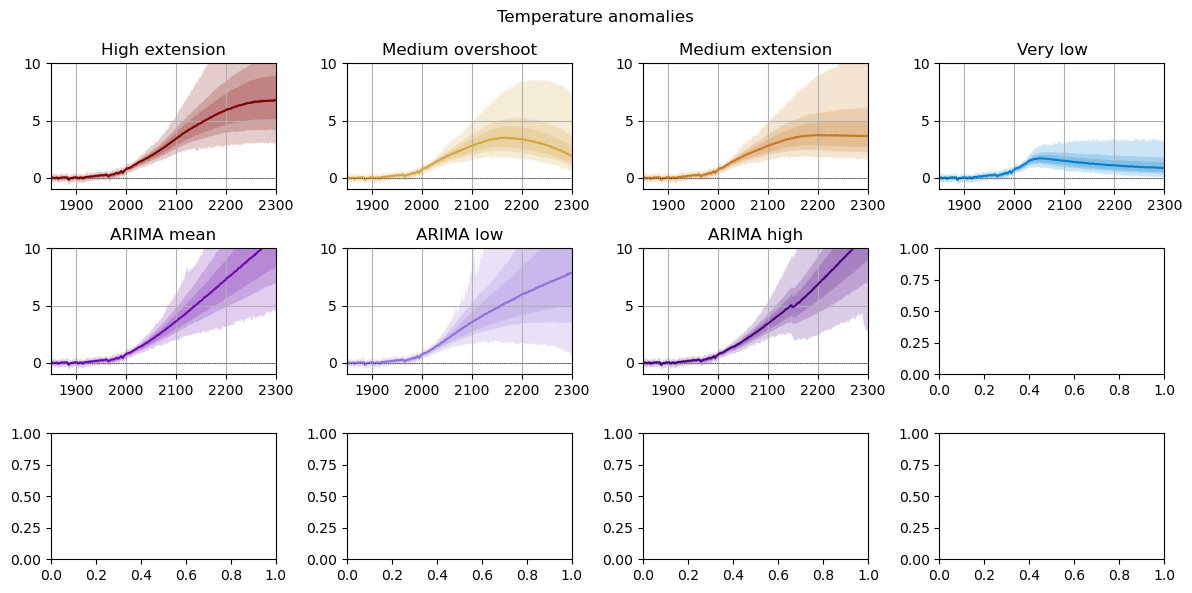

In [16]:
fig, ax = pl.subplots(3, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.temperature.loc[dict(scenario=scenario, layer=0)]
            - np.average(
                f.temperature.loc[
                    dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                ],
                weights=weights_51yr,
                axis=0
            ),
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-1, 10)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()
    
pl.suptitle("Temperature anomalies")
fig.tight_layout()

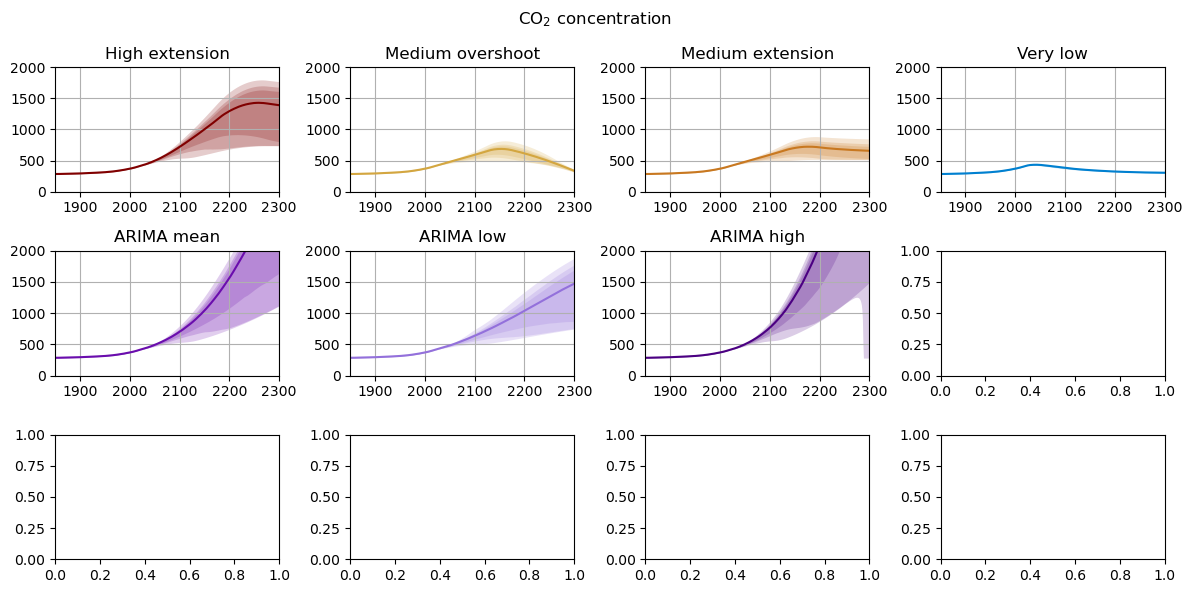

In [17]:
fig, ax = pl.subplots(3, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.concentration.loc[dict(scenario=scenario, specie='CO2')],
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.concentration.loc[dict(scenario=scenario, specie='CO2')],
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.concentration.loc[dict(scenario=scenario, specie='CO2')],
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(0, 2000)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()
    
pl.suptitle("CO$_2$ concentration")
fig.tight_layout()

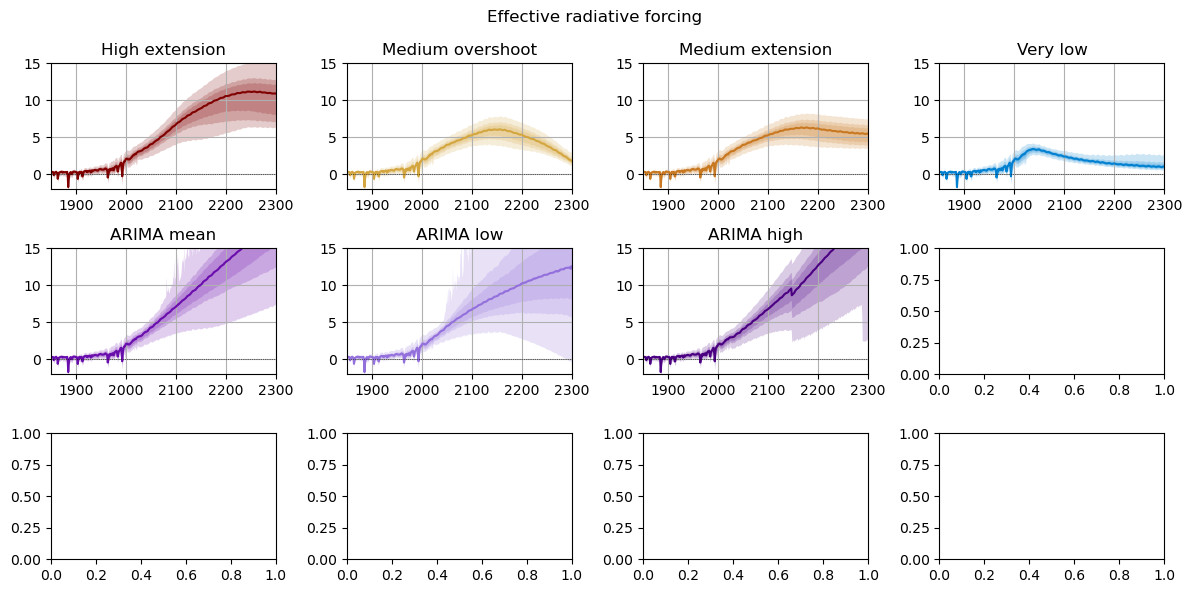

In [18]:
fig, ax = pl.subplots(3, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.forcing_sum.loc[dict(scenario=scenario)],
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.forcing_sum.loc[dict(scenario=scenario)],
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.forcing_sum.loc[dict(scenario=scenario)],
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-2, 15)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()

pl.suptitle("Effective radiative forcing")
fig.tight_layout()